In [1]:
import pandas as pd
import ir_datasets
from src.data import DATA_DIR_INTERIM
from topic_gen.evaluate import QrelsEvaluator, CohenKappa, MeanAverageError, AreaUnderReceiver, binarize_qrels
from src.data import load_qrels_from_path
from src.utils import format_score
from topic_gen import logger
logger.setLevel("DEBUG")

### Binary Relevance Labels

In [26]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

[topic_gen] [WARNING] (data.py:58) Metadata not found for result 2025-11-26_13:40:45, skipping...


In [27]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 19/2932 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 5/2946 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 12/2939 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Mi

In [28]:
df = pd.DataFrame(res)
df["score"] = df.apply(format_score, axis=1)
df = df.pivot(index="name", columns="measure", values="score").reset_index()
df = df.merge(metadata, left_on="name", right_on="date")

## Alignment
RQ: How well align generated qrels based on generated topics with the original qrels?
 
- Judgments based on the original topics are always better. Sometimes just a little!
- Some settings show a substantial drop in alignment, for example, for `qwen3-30B` on generated topics with the `trec` prompt with one query variant and one relevant document, the Cohen's $\kappa$ agreement to human labels drops from the substantial agreement of 0.75 to a moderate agreement of 0.52.
- More context always helps.
- Contrastive prompting is the best.

In [29]:
model = "qwen3-30B-no-think"  # df["model"]
prompt_sorter = [
    "human",
    "topic-query",
    "topic-docs-pos",
    "topic-docs-neg",
    "topic-query-docs-pos",
    "topic-query-docs-neg",
    "topic-contrastive",
    "topic-query-contrastive"
]
df["topics_prompt"] = pd.Categorical(df["topics_prompt"], prompt_sorter)

df[(df["prompt"] == "-DNA-zero-shot") & \
    #   (df["model"] == model) &
   ((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))] \
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["name", "topics_date", "topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

,name,topics_date,topics_prompt,model,topics_nqueries,topics_ndocspos,topics_ndocsneg,CohenKappa,MeanAverageError,AreaUnderReceiver
0,2025-11-25_10:03:54,2025-11-25_10:03:54,human,qwen3-30B-no-think,NaN,NaN,NaN,0.75 ± 0.03,0.10 ± 0.01,0.90 ± 0.01
1,2025-11-26_11:00:41,2025-11-25_13:07:46,topic-query,qwen3-30B-no-think,1.0,0.0,0.0,0.63 ± 0.02,0.18 ± 0.01,0.80 ± 0.01
2,2025-11-26_11:06:29,2025-11-25_13:08:31,topic-query,qwen3-30B-no-think,3.0,0.0,0.0,0.67 ± 0.03,0.16 ± 0.01,0.82 ± 0.01
3,2025-11-26_11:12:21,2025-11-25_13:09:17,topic-query,qwen3-30B-no-think,5.0,0.0,0.0,0.66 ± 0.03,0.16 ± 0.01,0.82 ± 0.02
4,2025-11-26_11:18:15,2025-11-25_13:10:06,topic-query,qwen3-30B-no-think,7.0,0.0,0.0,0.66 ± 0.02,0.16 ± 0.01,0.82 ± 0.01
5,2025-11-26_11:24:12,2025-11-25_13:10:56,topic-docs-pos,qwen3-30B-no-think,0.0,1.0,0.0,0.20 ± 0.02,0.47 ± 0.01,0.66 ± 0.01
6,2025-11-26_11:30:09,2025-11-25_13:12:14,topic-docs-pos,qwen3-30B-no-think,0.0,2.0,0.0,0.25 ± 0.02,0.43 ± 0.02,0.67 ± 0.01
7,2025-11-26_11:36:03,2025-11-25_13:14:00,topic-docs-pos,qwen3-30B-no-think,0.0,3.0,0.0,0.32 ± 0.03,0.37 ± 0.01,0.69 ± 0.01
8,2025-11-26_11:41:58,2025-11-25_13:16:07,topic-docs-pos,qwen3-30B-no-think,0.0,4.0,0.0,0.39 ± 0.02,0.32 ± 0.02,0.72 ± 0.01
9,2025-11-26_11:47:56,2025-11-25_13:18:43,topic-docs-pos,qwen3-30B-no-think,0.0,5.0,0.0,0.44 ± 0.03,0.29 ± 0.01,0.73 ± 0.01


## Plot 

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (data.py:58) Metadata not found for result 2025-11-26_13:40:45, skipping...
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 19/2932 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 5/2946 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 12/2939 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qre

In [74]:
df = pd.DataFrame(res)
df = df.merge(metadata, left_on="name", right_on="date")

In [98]:
df.topics_prompt.unique()

array(['topic-contrastive', 'topic-docs-pos', 'topic-docs-neg',
       'topic-query-docs-pos', 'topic-query-docs-neg', 'topic-query',
       'human'], dtype=object)

In [ ]:
def plot(subset_prompt_list, df, x = "topics_nqueries"):
    df = df.copy()
    baseline = df[df["topics_prompt"] == "human"]
    df = df[df["topics_prompt"].isin(subset_prompt_list)]
    unique_prompts = df["topics_prompt"].unique()
    palette = sns.color_palette("tab10", len(unique_prompts))
    color_map = dict(zip(unique_prompts, palette))

    for measure_name, g in df.groupby("measure"):
        fig, ax = plt.subplots(figsize=(4, 3))
        g = g.copy()
        g['ci_lower'] = g['value'] - g['ci']
        g['ci_upper'] = g['value'] + g['ci']

        sns.lineplot(
            data=g,
            x=x,
            y="value",
            hue="topics_prompt",
            palette=color_map,
            ax=ax,
            errorbar=None
        )
        for prompt_name, sub_g in g.groupby("topics_prompt"):
            sub_g = sub_g.sort_values(x)
            color = color_map[prompt_name]

            ax.fill_between(
                sub_g[x],
                sub_g['ci_lower'],
                sub_g['ci_upper'],
                color=color,
                alpha=0.15
            )

        ax.axhline(y=float(baseline[baseline["measure"] == measure_name]["value"].iloc[0]), linestyle='--',
                   label=f"Original Topic", color='gray')
        ax.set_title(f"Measure: {measure_name}")

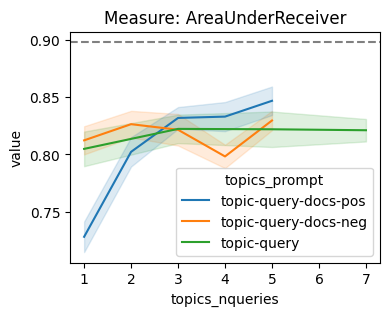

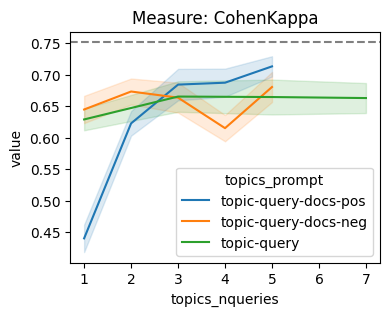

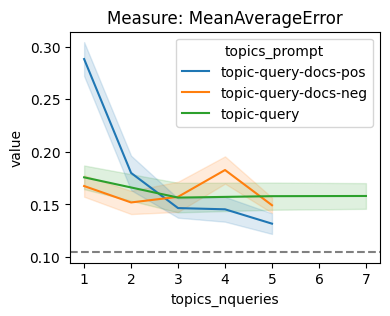

In [99]:
plot(['topic-query-docs-pos', 'topic-query-docs-neg', 'topic-query', 'topic-query-contrastive'], df)

### Per-Topic

In [13]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

[topic_gen] [WARNING] (data.py:58) Metadata not found for result 2025-11-26_13:34:47, skipping...


In [14]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    # bootstrap=20,
    per_query=True,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class 

In [17]:
df = pd.DataFrame(res)

In [18]:
summary = df.groupby(["topic_id", "measure"])["value"].describe().reset_index()

<Axes: >

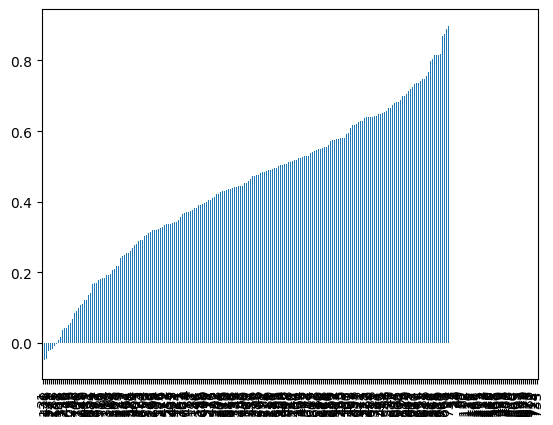

In [ ]:
summary[summary["measure"] == "CohenKappa"].sort_values(
    by="mean", ascending=True)["mean"].plot(kind='bar')

In [20]:
df[df["topic_id"] == "309"]

,topic_id,measure,value,name
24,309,CohenKappa,NaN,2025-11-26_13:22:54
25,309,MeanAverageError,0.0,2025-11-26_13:22:54
26,309,AreaUnderReceiver,NaN,2025-11-26_13:22:54
768,309,CohenKappa,NaN,2025-11-26_11:47:56
769,309,MeanAverageError,0.0,2025-11-26_11:47:56
...,...,...,...,...
18625,309,MeanAverageError,0.0,2025-11-26_13:11:00
18626,309,AreaUnderReceiver,NaN,2025-11-26_13:11:00
19368,309,CohenKappa,NaN,2025-11-26_11:24:12
19369,309,MeanAverageError,0.0,2025-11-26_11:24:12
